In [1]:
#Importing Libraries & Data Load
#pip install pandas numpy matplotlib seaborn scikit-learn joblib

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import joblib

# Define the path to the Excel file
file_path = r"C:\Users\cu16b\OneDrive\Documents\Prediction_Data.xlsx"

 # Define the sheet name to read data from
sheet_name = 'vw_ChurnData'

 # Read the data from the specified sheet into a pandas DataFrame
data = pd.read_excel(file_path, sheet_name=sheet_name)

 # Display the first few rows of the fetched data
print(data.head())

  Customer_ID  Gender  Age Married        State  Number_of_Referrals  \
0   11814-GUJ  Female   45     Yes      Gujarat                   12   
1   11850-MAH    Male   74     Yes  Maharashtra                    5   
2   11873-HAR    Male   45     Yes      Haryana                    9   
3   11878-RAJ    Male   75     Yes    Rajasthan                   15   
4   11882-BIH  Female   74      No        Bihar                   14   

   Tenure_in_Months Value_Deal Phone_Service Multiple_Lines  ...  \
0                 9        NaN           Yes            Yes  ...   
1                 6        NaN           Yes            Yes  ...   
2                10     Deal 2           Yes             No  ...   
3                17        NaN           Yes             No  ...   
4                15     Deal 5           Yes             No  ...   

    Payment_Method Monthly_Charge Total_Charges Total_Refunds  \
0  Bank Withdrawal     105.550003   6281.450195           0.0   
1      Credit Card      75.1

In [2]:
#DATA PREPROCESSING

#Reload fresh data
data = pd.read_excel(file_path, sheet_name=sheet_name)

# Drop columns that won't be used for prediction
data = data.drop(['Customer_ID', 'Churn_Category', 'Churn_Reason'], axis=1, errors='ignore')

# List of columns to be label encoded
columns_to_encode = [
    'Gender', 'Married', 'State', 'Value_Deal', 'Phone_Service', 'Multiple_Lines',
    'Internet_Service', 'Internet_Type', 'Online_Security', 'Online_Backup',
    'Device_Protection_Plan', 'Premium_Support', 'Streaming_TV', 'Streaming_Movies',
    'Streaming_Music', 'Unlimited_Data', 'Contract', 'Paperless_Billing',
    'Payment_Method'
]
# Encode categorical variables except the target variable
label_encoders = {}
for column in columns_to_encode:
    label_encoders[column] = LabelEncoder()
    data[column] = label_encoders[column].fit_transform(data[column])

# Manually encode the target variable 'Customer_Status'
data['Customer_Status'] = data['Customer_Status'].map({'Stayed': 0, 'Churned': 1})

# Split data into features and target
X = data.drop('Customer_Status', axis=1)
y = data['Customer_Status']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Confusion Matrix:
[[817  37]
 [135 213]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.96      0.90       854
           1       0.85      0.61      0.71       348

    accuracy                           0.86      1202
   macro avg       0.86      0.78      0.81      1202
weighted avg       0.86      0.86      0.85      1202



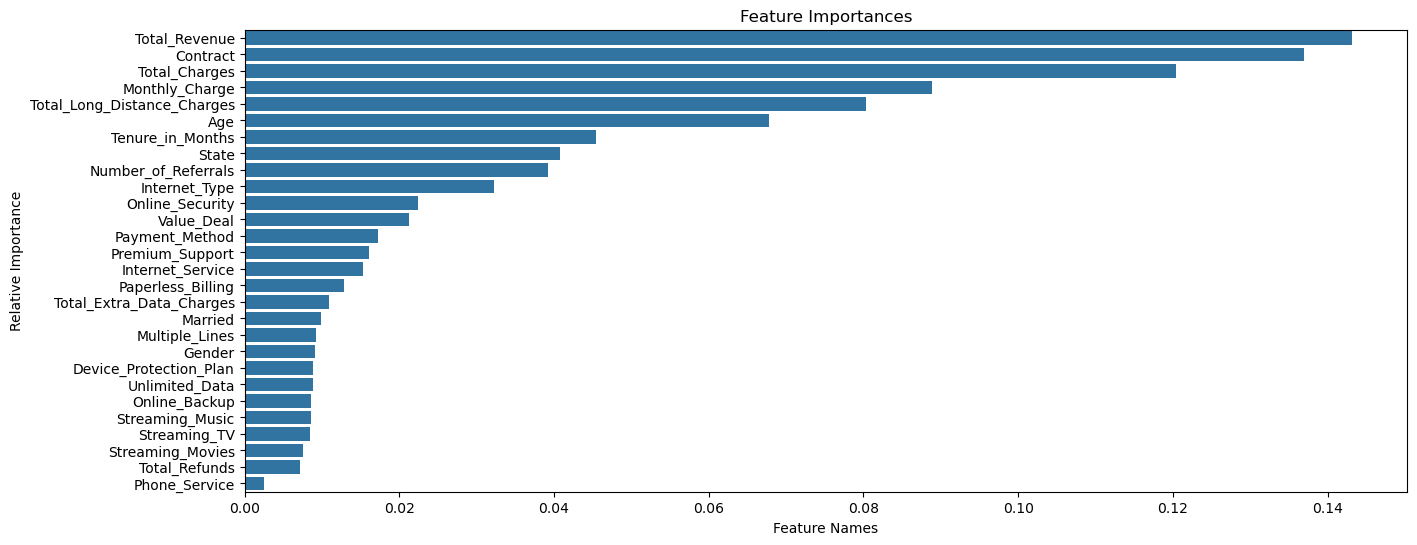

In [3]:
#TRAIN RANDOM FOREST MODEL

# Initialize the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

#EVALUATE MODEL
# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

 
# Feature Selection using Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

 
# Plot the feature importances
plt.figure(figsize=(15, 6))
sns.barplot(x=importances[indices], y=X.columns[indices])
plt.title('Feature Importances')
plt.xlabel('Feature Names')
plt.ylabel('Relative Importance')
plt.show()

In [4]:
#USE MODEL FOR PREDICTION ON NEW DATA
#Define the path to the Joiner Data Excel file
file_path = r"C:\Users\cu16b\OneDrive\Documents\Prediction_Data.xlsx"

# Define the sheet name to read data from
sheet_name = 'vw_JoinData'

# Read the data from the specified sheet into a pandas DataFrame
new_data = pd.read_excel(file_path, sheet_name=sheet_name)

# Display the first few rows of the fetched data
print(new_data.head())

# Retain the original DataFrame to preserve unencoded columns
original_data = new_data.copy()

# Retain the Customer_ID column
customer_ids = new_data['Customer_ID']

# Drop columns that won't be used for prediction in the encoded DataFrame
new_data = new_data.drop(['Customer_ID', 'Customer_Status', 'Churn_Category', 'Churn_Reason'], axis=1, errors='ignore')

# Encode categorical variables using the saved label encoders
for column in new_data.select_dtypes(include=['str']).columns:
    if column in label_encoders:
       new_data[column] = label_encoders[column].transform(new_data[column])

# Make predictions
new_predictions = rf_model.predict(new_data)

# Add predictions to the original DataFrame
original_data['Customer_Status_Predicted'] = new_predictions

# Filter the DataFrame to include only records predicted as "Churned"
original_data = original_data[original_data['Customer_Status_Predicted'] == 1]

# Save the results
original_data.to_csv("Predictions.csv", index=False)

  Customer_ID  Gender  Age Married          State  Number_of_Referrals  \
0   15591-KAR  Female   26      No      Karnataka                    3   
1   17597-HAR  Female   33     Yes        Haryana                    2   
2   17796-BIH  Female   65      No          Bihar                    5   
3   18027-UTT  Female   58     Yes  Uttar Pradesh                   15   
4   21642-TEL    Male   60     Yes      Telangana                   12   

   Tenure_in_Months Value_Deal Phone_Service Multiple_Lines  ...  \
0                31        NaN           Yes             No  ...   
1                 6     Deal 5            No             No  ...   
2                 1        NaN           Yes             No  ...   
3                30     Deal 5           Yes             No  ...   
4                29        NaN           Yes             No  ...   

    Payment_Method Monthly_Charge Total_Charges Total_Refunds  \
0      Credit Card      20.400000     20.400000           0.0   
1  Bank Withdraw